### Train


In [1]:
import copy
import time

import torch
from torchvision.datasets import FashionMNIST
from torchvision import transforms
import torch.utils.data as Data
import numpy as np
import matplotlib.pyplot as plt
from model import Residual, ResNet18
import torch.nn as nn
import pandas as pd


In [2]:
def train_val_data_process():
    train_data = FashionMNIST(root='./data',
                              train=True,
                              transform=transforms.Compose([transforms.Resize(size=224), transforms.ToTensor()]),
                              download=True)

    train_data, val_data = Data.random_split(train_data, [round(0.8*len(train_data)), round(0.2*len(train_data))])
    train_dataloader = Data.DataLoader(dataset=train_data,
                                       batch_size=32,
                                       shuffle=True,
                                       num_workers=2)

    val_dataloader = Data.DataLoader(dataset=val_data,
                                       batch_size=32,
                                       shuffle=True,
                                       num_workers=2)

    return train_dataloader, val_dataloader

In [3]:
def train_model_process(model, train_dataloader, val_dataloader, num_epochs):
    # 设定训练所用到的设备，有GPU用GPU没有GPU用CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # 使用Adam优化器，学习率为0.001
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    # 损失函数为交叉熵函数
    criterion = nn.CrossEntropyLoss()
    # 将模型放入到训练设备中
    model = model.to(device)
    # 复制当前模型的参数
    best_model_wts = copy.deepcopy(model.state_dict())

    # 初始化参数
    # 最高准确度
    best_acc = 0.0
    # 训练集损失列表
    train_loss_all = []
    # 验证集损失列表
    val_loss_all = []
    # 训练集准确度列表
    train_acc_all = []
    # 验证集准确度列表
    val_acc_all = []
    # 当前时间
    since = time.time()

    for epoch in range(num_epochs):
        print("Epoch {}/{}".format(epoch, num_epochs-1))
        print("-"*10)

        # 初始化参数
        # 训练集损失函数
        train_loss = 0.0
        # 训练集准确度
        train_corrects = 0
        # 验证集损失函数
        val_loss = 0.0
        # 验证集准确度
        val_corrects = 0
        # 训练集样本数量
        train_num = 0
        # 验证集样本数量
        val_num = 0

        # 对每一个mini-batch训练和计算
        for step, (b_x, b_y) in enumerate(train_dataloader):
            # 将特征放入到训练设备中
            b_x = b_x.to(device)
            # 将标签放入到训练设备中
            b_y = b_y.to(device)
            # 设置模型为训练模式
            model.train()

            # 前向传播过程，输入为一个batch，输出为一个batch中对应的预测
            output = model(b_x)
            # 查找每一行中最大值对应的行标
            pre_lab = torch.argmax(output, dim=1)
            # 计算每一个batch的损失函数
            loss = criterion(output, b_y)

            # 将梯度初始化为0
            optimizer.zero_grad()
            # 反向传播计算
            loss.backward()
            # 根据网络反向传播的梯度信息来更新网络的参数，以起到降低loss函数计算值的作用
            optimizer.step()
            # 对损失函数进行累加
            train_loss += loss.item() * b_x.size(0)
            # 如果预测正确，则准确度train_corrects加1
            train_corrects += torch.sum(pre_lab == b_y.data)
            # 当前用于训练的样本数量
            train_num += b_x.size(0)
        for step, (b_x, b_y) in enumerate(val_dataloader):
            # 将特征放入到验证设备中
            b_x = b_x.to(device)
            # 将标签放入到验证设备中
            b_y = b_y.to(device)
            # 设置模型为评估模式
            model.eval()
            # 前向传播过程，输入为一个batch，输出为一个batch中对应的预测
            output = model(b_x)
            # 查找每一行中最大值对应的行标
            pre_lab = torch.argmax(output, dim=1)
            # 计算每一个batch的损失函数
            loss = criterion(output, b_y)


            # 对损失函数进行累加
            val_loss += loss.item() * b_x.size(0)
            # 如果预测正确，则准确度train_corrects加1
            val_corrects += torch.sum(pre_lab == b_y.data)
            # 当前用于验证的样本数量
            val_num += b_x.size(0)

        # 计算并保存每一次迭代的loss值和准确率
        # 计算并保存训练集的loss值
        train_loss_all.append(train_loss / train_num)
        # 计算并保存训练集的准确率
        train_acc_all.append(train_corrects.double().item() / train_num)

        # 计算并保存验证集的loss值
        val_loss_all.append(val_loss / val_num)
        # 计算并保存验证集的准确率
        val_acc_all.append(val_corrects.double().item() / val_num)

        print("{} train loss:{:.4f} train acc: {:.4f}".format(epoch, train_loss_all[-1], train_acc_all[-1]))
        print("{} val loss:{:.4f} val acc: {:.4f}".format(epoch, val_loss_all[-1], val_acc_all[-1]))

        if val_acc_all[-1] > best_acc:
            # 保存当前最高准确度
            best_acc = val_acc_all[-1]
            # 保存当前最高准确度的模型参数
            best_model_wts = copy.deepcopy(model.state_dict())

        # 计算训练和验证的耗时
        time_use = time.time() - since
        print("训练和验证耗费的时间{:.0f}m{:.0f}s".format(time_use//60, time_use%60))

    # 选择最优参数，保存最优参数的模型
    model.load_state_dict(best_model_wts)
    
    torch.save(best_model_wts, r".\best_ResNet.pth")


    train_process = pd.DataFrame(data={"epoch":range(num_epochs),
                                       "train_loss_all":train_loss_all,
                                       "val_loss_all":val_loss_all,
                                       "train_acc_all":train_acc_all,
                                       "val_acc_all":val_acc_all,})

    return train_process


In [4]:
def matplot_acc_loss(train_process):
    # 显示每一次迭代后的训练集和验证集的损失函数和准确率
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_process['epoch'], train_process.train_loss_all, "ro-", label="Train loss")
    plt.plot(train_process['epoch'], train_process.val_loss_all, "bs-", label="Val loss")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("Loss")
    plt.subplot(1, 2, 2)
    plt.plot(train_process['epoch'], train_process.train_acc_all, "ro-", label="Train acc")
    plt.plot(train_process['epoch'], train_process.val_acc_all, "bs-", label="Val acc")
    plt.xlabel("epoch")
    plt.ylabel("acc")
    plt.legend()
    plt.show()


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.9MB/s]


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 150kB/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.61MB/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

Epoch 0/19
----------
0 train loss:0.4612 train acc: 0.8310
0 val loss:0.3503 val acc: 0.8705
训练和验证耗费的时间2m0s
Epoch 1/19
----------
1 train loss:0.2866 train acc: 0.8968
1 val loss:0.2901 val acc: 0.8914
训练和验证耗费的时间3m55s
Epoch 2/19
----------
2 train loss:0.2383 train acc: 0.9125
2 val loss:0.2374 val acc: 0.9140
训练和验证耗费的时间5m50s
Epoch 3/19
----------
3 train loss:0.2067 train acc: 0.9239
3 val loss:0.2151 val acc: 0.9220
训练和验证耗费的时间7m45s
Epoch 4/19
----------
4 train loss:0.1754 train acc: 0.9360
4 val loss:0.2125 val acc: 0.9244
训练和验证耗费的时间9m41s
Epoch 5/19
----------
5 train loss:0.1468 train acc: 0.9464
5 val loss:0.2105 val acc: 0.9238
训练和验证耗费的时间11m36s
Epoch 6/19
----------
6 train loss:0.1180 train acc: 0.9573
6 val loss:0.2464 val acc: 0.9173
训练和验证耗费的时间13m31s
Epoch 7/19
----------
7 train loss:0.0949 train acc: 0.9656
7 val loss:0.2837 val acc: 0.9133
训练和验证耗费的时间15m27s
Epoch 8/19
----------
8 train

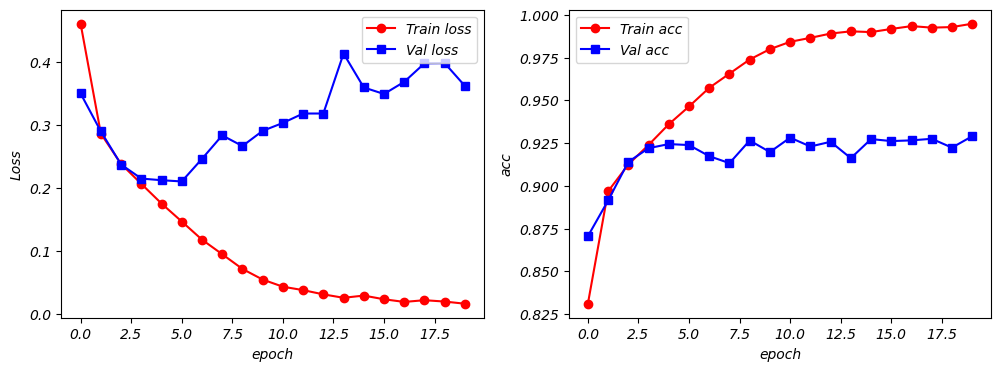

In [5]:
if __name__ == '__main__':
    # 加载需要的模型
    ResNet18 = ResNet18(Residual)
    # 加载数据集
    train_data, val_data = train_val_data_process()
    # 利用现有的模型进行模型的训练
    train_process = train_model_process(ResNet18, train_data, val_data, num_epochs=20)
    matplot_acc_loss(train_process)